# English-Hindi Translation with Encoder-Decoder RNN + Attention

This notebook implements a seq2seq model with attention for English to Hindi translation using PyTorch.

## 1. Install & Import Dependencies

In [33]:
!pip install torch datasets sacremoses -q

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from collections import Counter
import re
import random
import numpy as np
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Prepare Data

In [35]:
# Load IIT Bombay English-Hindi dataset
dataset = load_dataset("cfilt/iitb-english-hindi")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})


In [36]:
# Look at some examples
print("Example:")
print(dataset['train'][0])

Example:
{'translation': {'en': 'Give your application an accessibility workout', 'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}


In [37]:
# Use a subset for faster training (can increase later)
MAX_SAMPLES = 100000  # Use 100k samples for training

train_data = dataset['train']['translation'][:MAX_SAMPLES]

english_sentences = [item['en'] for item in train_data]
hindi_sentences = [item['hi'] for item in train_data]

print(f"Total training samples: {len(english_sentences)}")
print(f"Sample English: {english_sentences[0]}")
print(f"Sample Hindi: {hindi_sentences[0]}")

Total training samples: 100000
Sample English: Give your application an accessibility workout
Sample Hindi: अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें


## 3. Tokenizer (Character-level)

In [38]:
class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.PAD_token = 0
        self.SOS_token = 1
        self.EOS_token = 2
        self.UNK_token = 3

        self.token2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2token = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.n_tokens = 4

    def add_sentence(self, sentence):
        for char in sentence:
            if char not in self.token2idx:
                self.token2idx[char] = self.n_tokens
                self.idx2token[self.n_tokens] = char
                self.n_tokens += 1

    def encode(self, sentence, max_len=None):
        indices = [self.token2idx.get(c, self.UNK_token) for c in sentence]
        indices.append(self.EOS_token)
        if max_len:
            indices = indices[:max_len]
            indices += [self.PAD_token] * (max_len - len(indices))
        return indices

    def decode(self, indices):
        chars = []
        for idx in indices:
            if idx == self.EOS_token:
                break
            if idx not in [self.PAD_token, self.SOS_token]:
                chars.append(self.idx2token.get(idx, '<UNK>'))
        return ''.join(chars)

# Build vocabularies
eng_vocab = Vocabulary('english')
hin_vocab = Vocabulary('hindi')

print("Building vocabularies...")
for sent in english_sentences:
    eng_vocab.add_sentence(sent)
for sent in hindi_sentences:
    hin_vocab.add_sentence(sent)

print(f"English vocab size: {eng_vocab.n_tokens}")
print(f"Hindi vocab size: {hin_vocab.n_tokens}")

Building vocabularies...
English vocab size: 110
Hindi vocab size: 175


## 4. Dataset & DataLoader

In [ ]:
MAX_SEQ_LEN = 100

class TranslationDataset(Dataset):
    def __init__(self, english, hindi, eng_vocab, hin_vocab, max_len):
        self.english = english
        self.hindi = hindi
        self.eng_vocab = eng_vocab
        self.hin_vocab = hin_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.english)

    def __getitem__(self, idx):
        eng = self.english[idx]
        hin = self.hindi[idx]

        eng_enc = self.eng_vocab.encode(eng, self.max_len)
        hin_enc = self.hin_vocab.encode(hin, self.max_len)

        return (
            torch.tensor(eng_enc, dtype=torch.long),
            torch.tensor(hin_enc, dtype=torch.long)
        )

dataset = TranslationDataset(english_sentences, hindi_sentences, eng_vocab, hin_vocab, MAX_SEQ_LEN)

train_size = int(0.95 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 1485
Val batches: 79


## 5. Model: Encoder-Decoder with Attention

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers,
                           batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)

        # Combine bidirectional hidden states
        # hidden: (num_layers * 2, batch, hidden_size)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden_size*2)
        hidden = torch.tanh(self.fc(hidden))  # (batch, hidden_size)

        cell = torch.cat([cell[-2], cell[-1]], dim=1)
        cell = torch.tanh(self.fc(cell))

        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)  # cell: (1, batch, hidden)


class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 3, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch, hidden_size)
        # encoder_outputs: (batch, seq_len, hidden_size*2)

        batch_size = encoder_outputs.shape[0]
        seq_len = encoder_outputs.shape[1]

        # Reshape hidden to (batch, seq_len, hidden_size) for concatenation
        # hidden.squeeze(0) changes (1, batch, hidden_size) to (batch, hidden_size)
        # .unsqueeze(1) changes (batch, hidden_size) to (batch, 1, hidden_size)
        # .repeat(1, seq_len, 1) repeats this along the sequence dimension
        hidden = hidden.squeeze(0).unsqueeze(1).repeat(1, seq_len, 1)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)  # (batch, seq_len)

        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attention = Attention(hidden_size)
        self.lstm = nn.LSTM(embed_size + hidden_size * 2, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size * 3 + embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        # x: (batch, 1) - single timestep
        # hidden: (num_layers, batch, hidden_size)
        # encoder_outputs: (batch, seq_len, hidden_size*2)

        embedded = self.dropout(self.embedding(x))  # (batch, 1, embed_size)

        # Pass only the last layer's hidden state to attention
        attn_weights = self.attention(hidden[-1].unsqueeze(0), encoder_outputs)  # (batch, seq_len)
        attn_weights = attn_weights.unsqueeze(1)  # (batch, 1, seq_len)

        context = torch.bmm(attn_weights, encoder_outputs)  # (batch, 1, hidden_size*2)

        lstm_input = torch.cat((embedded, context), dim=2)  # (batch, 1, embed_size + hidden*2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        # output: (batch, 1, hidden_size)
        output = self.fc(torch.cat((output, context, embedded), dim=2).squeeze(1))

        return output, hidden, cell, attn_weights.squeeze(1)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (batch, src_seq_len)
        # trg: (batch, trg_seq_len)

        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        # Replicate hidden and cell states for decoder's num_layers
        hidden = hidden.repeat(self.decoder.lstm.num_layers, 1, 1)
        cell = cell.repeat(self.decoder.lstm.num_layers, 1, 1)

        # Use SOS as first input
        decoder_input = torch.ones(batch_size, 1, dtype=torch.long).to(self.device)  # <SOS>

        for t in range(trg_len):
            output, hidden, cell, _ = self.decoder(decoder_input, hidden, cell, encoder_outputs)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            decoder_input = trg[:, t].unsqueeze(1) if teacher_force else top1.unsqueeze(1)

        return outputs

    def translate(self, src, max_len=100):
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, cell = self.encoder(src)

            # Replicate hidden and cell states for decoder's num_layers
            hidden = hidden.repeat(self.decoder.lstm.num_layers, 1, 1)
            cell = cell.repeat(self.decoder.lstm.num_layers, 1, 1)

            decoder_input = torch.ones(1, 1, dtype=torch.long).to(self.device)

            result = []
            attention_weights = []

            for _ in range(max_len):
                output, hidden, cell, attn = self.decoder(decoder_input, hidden, cell, encoder_outputs)

                top1 = output.argmax(1).item()
                result.append(top1)
                attention_weights.append(attn.cpu())

                if top1 == 2:  # <EOS>
                    break

                decoder_input = torch.tensor([[top1]]).to(self.device)

            return result, attention_weights

## 6. Initialize Model

In [41]:
# Hyperparameters
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001

encoder = Encoder(eng_vocab.n_tokens, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
decoder = Decoder(hin_vocab.n_tokens, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder, device).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 16,927,919


## 7. Training Loop

In [42]:
NUM_EPOCHS = 8

# Google Drive backup setup (works in Colab)
try:
    from google.colab import drive
    import shutil
    import os

    drive.mount('/content/drive')
    BEST_MODEL_DRIVE_PATH = '/content/drive/MyDrive/best_model.pt'

    def upload_to_drive(local_path, drive_path):
        drive_dir = os.path.dirname(drive_path)
        os.makedirs(drive_dir, exist_ok=True)
        shutil.copy(local_path, drive_path)
        print(f"Uploaded {local_path} to {drive_path}")

    DRIVE_BACKUP_ENABLED = True
except ImportError:
    DRIVE_BACKUP_ENABLED = False
    print("Not running in Google Colab. Drive backup disabled.")

def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0

    for src, trg in tqdm(loader, desc="Training"):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        # Reshape for loss
        output = output.view(-1, output.shape[-1])
        trg = trg.view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in tqdm(loader, desc="Evaluating"):
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0)

            output = output.view(-1, output.shape[-1])
            trg = trg.view(-1)

            loss = criterion(output, trg)
            total_loss += loss.item()

    return total_loss / len(loader)


best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} ===")

    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # Save current epoch model locally
    torch.save(model.state_dict(), 'best_model.pt')

    # Upload every epoch to Google Drive
    if DRIVE_BACKUP_ENABLED:
        upload_to_drive('best_model.pt', BEST_MODEL_DRIVE_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("Saved best model!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Epoch 1/8 ===


Evaluating: 100%|██████████| 79/79 [00:36<00:00,  2.19it/s]


Train Loss: 2.2144
Val Loss: 3.0165
Uploaded best_model.pt to /content/drive/MyDrive/best_model.pt
Saved best model!

=== Epoch 2/8 ===


Evaluating: 100%|██████████| 79/79 [00:35<00:00,  2.21it/s]


Train Loss: 1.1992
Val Loss: 2.5527
Uploaded best_model.pt to /content/drive/MyDrive/best_model.pt
Saved best model!

=== Epoch 3/8 ===


...

Train Loss: 0.5415
Val Loss: 1.9241
Uploaded best_model.pt to /content/drive/MyDrive/best_model.pt
Saved best model!

=== Epoch 7/8 ===


Evaluating: 100%|██████████| 79/79 [00:34<00:00,  2.28it/s]


Train Loss: 0.4913
Val Loss: 1.8466
Uploaded best_model.pt to /content/drive/MyDrive/best_model.pt
Saved best model!

=== Epoch 8/8 ===


Evaluating: 100%|██████████| 79/79 [00:35<00:00,  2.22it/s]


Train Loss: 0.4580
Val Loss: 1.7986
Uploaded best_model.pt to /content/drive/MyDrive/best_model.pt
Saved best model!


## 8. Inference & Attention Visualization

In [43]:
# Load best model
model.load_state_dict(torch.load('best_model.pt'))

def translate_sentence(sentence, model, eng_vocab, hin_vocab, max_len=100):
    model.eval()

    tokens = eng_vocab.encode(sentence, max_len)
    src = torch.tensor(tokens).unsqueeze(0).to(device)

    result, attn_weights = model.translate(src, max_len)

    hindi_translation = hin_vocab.decode(result)

    return hindi_translation, attn_weights


# Test on some examples
test_samples = [
    "hello how are you",
    "i love machine learning",
    "what is your name",
    "good morning",
    "thank you very much"
]

print("=== Translations ===\n")
for sample in test_samples:
    translation, _ = translate_sentence(sample, model, eng_vocab, hin_vocab)
    print(f"English: {sample}")
    print(f"Hindi: {translation}\n")

=== Translations ===

English: hello how are you
Hindi: इसको आप क्या आप लेने हैं

English: i love machine learning
Hindi: मश्दी  में लेखन का द खाली देखें

English: what is your name
Hindi: आपका नाम के प्रति प्राहै

English: good morning
Hindi: रेता मारित 

English: thank you very much
Hindi: चुने आप े केंजी नहीं



## 9. Visualize Attention

/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1497819322.py:29: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyth

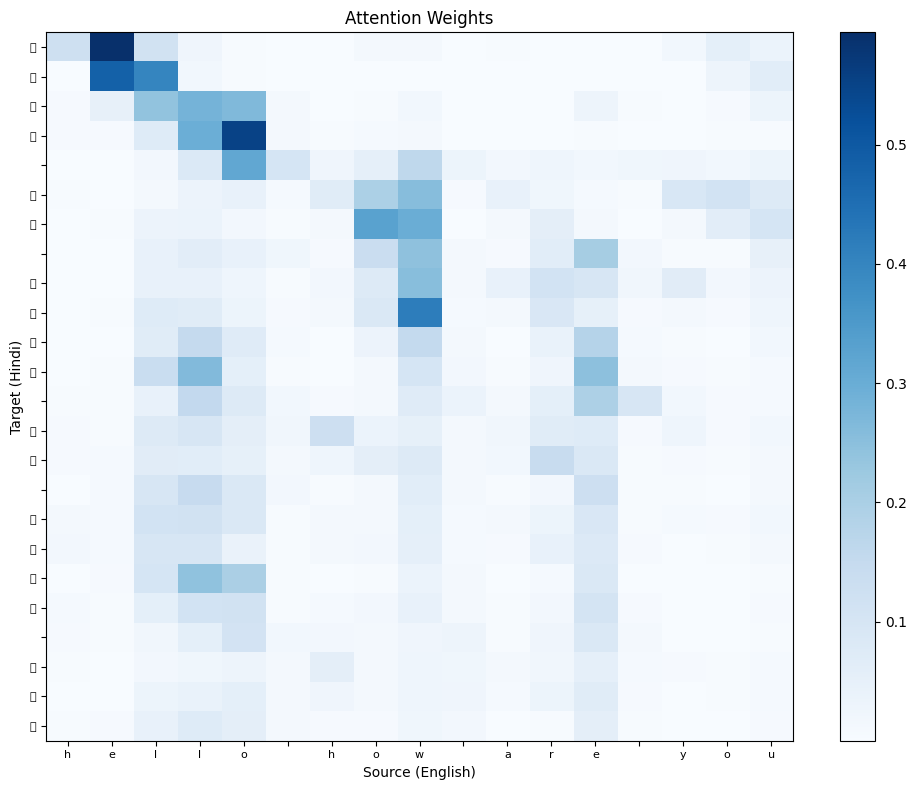

In [44]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']

def plot_attention(src, translation, attention_weights):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Convert attention to numpy
    attn = torch.stack(attention_weights).squeeze().cpu().numpy()

    # Trim to actual lengths
    src_len = len(src)
    trg_len = len(translation)

    attn = attn[:trg_len, :src_len]

    im = ax.imshow(attn, cmap='Blues', aspect='auto')

    ax.set_xticks(range(src_len))
    ax.set_yticks(range(trg_len))
    ax.set_xticklabels(list(src), fontsize=8)
    ax.set_yticklabels(list(translation), fontsize=8)

    ax.set_xlabel('Source (English)')
    ax.set_ylabel('Target (Hindi)')
    ax.set_title('Attention Weights')

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# Plot attention for first test sentence
sample = test_samples[0]
translation, attn_weights = translate_sentence(sample, model, eng_vocab, hin_vocab)
plot_attention(sample, translation, attn_weights)

## 10. Save Model & Vocab

In [45]:
import pickle

# Save model and vocabularies
torch.save({
    'encoder': encoder.state_dict(),
    'decoder': decoder.state_dict(),
    'optimizer': optimizer.state_dict(),
    'epoch': NUM_EPOCHS
}, 'translation_model.pt')

with open('vocab.pkl', 'wb') as f:
    pickle.dump({'eng_vocab': eng_vocab, 'hin_vocab': hin_vocab}, f)

print("Model and vocabularies saved!")
print("- translation_model.pt")
print("- vocab.pkl")

Model and vocabularies saved!
- translation_model.pt
- vocab.pkl
